## This is a sample pandas project that exemplifies how to proceed data wrangling, specifically for data science and machine learning purposes, using Python, Pandas, NumPy, Matplotlib, Seaborn and xlrd

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# xlrd dependence (although already installed) is not needed at this project, as the spreadsheets are already in the 
# modern xlsx format. openpyxl is another dependence (also already installed) used instead.

In [2]:
cvm_data = pd.read_csv('(3.2) CVM Resultado.csv', 
                        sep=';',
                        encoding='latin1')

registration_data = pd.read_csv('(3.3) CVM Dados Cadastrais.csv', 
                        sep=';',
                        encoding='latin1')

In [3]:
# the main .csv is a dataset with some of the stocks at B3 Brazil, published by the federal CVM commission. We wanna 
# compare the variations on the revenue and profit / loss accounts, for each main sector.

In [4]:
cvm_data

,CNPJ_CIA,DT_REFER,VERSAO,DENOM_CIA,CD_CVM,GRUPO_DFP,MOEDA,ESCALA_MOEDA,ORDEM_EXERC,DT_INI_EXERC,DT_FIM_EXERC,CD_CONTA,DS_CONTA,VL_CONTA,ST_CONTA_FIXA
0,00.000.000/0001-91,2022-12-31,1,BCO BRASIL S.A.,1023,DF Consolidado - Demonstração do Resultado,REAL,MIL,PENÚLTIMO,2021-01-01,2021-12-31,3.01,Receitas de Intermediação Financeira,1.259472e+08,S
1,00.000.000/0001-91,2022-12-31,1,BCO BRASIL S.A.,1023,DF Consolidado - Demonstração do Resultado,REAL,MIL,ÚLTIMO,2022-01-01,2022-12-31,3.01,Receitas de Intermediação Financeira,2.365491e+08,S
2,00.000.000/0001-91,2022-12-31,1,BCO BRASIL S.A.,1023,DF Consolidado - Demonstração do Resultado,REAL,MIL,PENÚLTIMO,2021-01-01,2021-12-31,3.01.01,Receita de Juros,1.259472e+08,N
3,00.000.000/0001-91,2022-12-31,1,BCO BRASIL S.A.,1023,DF Consolidado - Demonstração do Resultado,REAL,MIL,ÚLTIMO,2022-01-01,2022-12-31,3.01.01,Receita de Juros,2.365491e+08,N
4,00.000.000/0001-91,2022-12-31,1,BCO BRASIL S.A.,1023,DF Consolidado - Demonstração do Resultado,REAL,MIL,PENÚLTIMO,2021-01-01,2021-12-31,3.02,Despesas de Intermediação Financeira,-6.627314e+07,S
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23479,97.837.181/0001-47,2022-12-31,1,DEXCO S.A.,21091,DF Consolidado - Demonstração do Resultado,REAL,MIL,ÚLTIMO,2022-01-01,2022-12-31,3.99.01.01,ON,1.017800e+00,N
23480,97.837.181/0001-47,2022-12-31,1,DEXCO S.A.,21091,DF Consolidado - Demonstração do Resultado,REAL,MIL,PENÚLTIMO,2021-01-01,2021-12-31,3.99.02,Lucro Diluído por Ação,0.000000e+00,N
23481,97.837.181/0001-47,2022-12-31,1,DEXCO S.A.,21091,DF Consolidado - Demonstração do Resultado,REAL,MIL,ÚLTIMO,2022-01-01,2022-12-31,3.99.02,Lucro Diluído por Ação,0.000000e+00,N
23482,97.837.181/0001-47,2022-12-31,1,DEXCO S.A.,21091,DF Consolidado - Demonstração do Resultado,REAL,MIL,PENÚLTIMO,2021-01-01,2021-12-31,3.99.02.01,ON,2.475400e+00,N


In [5]:
registration_data

,CNPJ_CIA,DENOM_SOCIAL,DENOM_COMERC,DT_REG,DT_CONST,DT_CANCEL,MOTIVO_CANCEL,SIT,DT_INI_SIT,CD_CVM,...,UF_RESP,PAIS_RESP,CEP_RESP,DDD_TEL_RESP,TEL_RESP,DDD_FAX_RESP,FAX_RESP,EMAIL_RESP,CNPJ_AUDITOR,AUDITOR
0,08.773.135/0001-00,2W ECOBANK S.A.,2W ECOBANK S.A.,2020-10-29,2007-03-23,NaN,NaN,ATIVO,2020-10-29,25224,...,SP,NaN,4707000.0,11,39579400.0,NaN,NaN,ri@2wenergia.com.br,61.366.936/0001-25,ERNST & YOUNG AUDITORES INDEPENDENTES S/S LTDA.
1,11.396.633/0001-87,3A COMPANHIA SECURITIZADORA,TRIPLO A COMPANHIA SECURITIZADORA,2010-03-08,2009-11-03,2015-12-18,Cancelamento Voluntário - IN CVM 480/09,CANCELADA,2015-12-18,21954,...,RJ,NaN,20020000.0,21,22338867.0,21.0,22338867.0,juridico@triploasec.com.br,60.525.706/0001-07,MOORE STEPHENS LIMA LUCCHESI AUDITORES INDEPEN...
2,12.091.809/0001-55,3R PETROLEUM OLÉO E GÁS S.A.,NaN,2020-11-09,2010-06-08,NaN,NaN,ATIVO,2020-11-09,25291,...,RJ,NaN,22250180.0,21,21455555.0,0.0,0.0,ri@3rpetroleum.com.br,57.755.217/0001-29,KPMG AUDITORES INDEPENDENTES LTDA.
3,01.547.749/0001-16,521 PARTICIPAÇOES S.A. - EM LIQUIDAÇÃO EXTRAJU...,521 PARTICIPAÇÕES S/A,1997-07-11,1996-07-30,NaN,NaN,ATIVO,1997-07-11,16330,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.596.945/0001-83,BAKER TILLY 4PARTNERS AUDITORES INDEPENDENTES S/S
4,01.851.771/0001-55,524 PARTICIPAÇOES SA,524 PARTICIPACOES SA,1997-05-30,1997-04-02,NaN,NaN,ATIVO,1997-05-30,16284,...,RJ,NaN,20020010.0,21,38043700.0,0.0,0.0,gar@opportunity.com.br,40.262.602/0001-31,"BKR - LOPES, MACHADO AUDITORES"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2566,13.574.594/0001-96,ZAMP S.A.,ZAMP S.A.,2017-12-14,2011-04-06,NaN,NaN,ATIVO,2017-12-14,24317,...,NaN,NaN,6455020.0,11,23970320.0,0.0,0.0,ri@burgerking.com.br,61.562.112/0001-20,PRICEWATERHOUSECOOPERS AUDITORES INDEPENDENTES...
2567,71.320.931/0001-15,ZANINI SA EQUIPS PESADOS,ZANINI,1971-07-05,NaN,1997-01-27,ATENDIMENTO AS NORMAS DA INSTR CVM 03/78,CANCELADA,1997-01-27,11835,...,SP,NaN,1013000.0,11,6424066.0,11.0,NaN,NaN,61.562.112/0001-20,PRICEWATERHOUSECOOPERS AUDITORES INDEPENDENTES...
2568,24.744.012/0001-99,ZH OPERAÇÕES S/A,ZH OPERAÇÕES S/A,2016-09-16,2016-04-15,2017-08-07,Cancelamento de ofício - IN CVM 480/09,CANCELADA,2017-08-07,24007,...,SP,NaN,4609005.0,011,50548989.0,NaN,NaN,renno@setaatacadista.com.br,00.115.909/0001-95,MS AUDITORES INDEPENDENTES S/C
2569,92.749.217/0001-17,ZIVI SA CUTELARIA,ZIVI S/A,1968-11-01,1931-01-01,2003-12-29,ELISÃO POR INCORPORAÇÃO,CANCELADA,2003-12-29,11843,...,RS,NaN,91030530.0,51,33585109.0,51.0,33585176.0,michael.ceitlin@gem.ind.br,61.562.112/0001-20,PRICEWATERHOUSECOOPERS AUDITORES INDEPENDENTES...


In [6]:
accounts = cvm_data['DS_CONTA'].unique()
accounts

# From the 1170 types of accounts at the df, we only need two types:
# "Receitas de Intermediação Financeira" -> CD_CONTA == "3.01
# and
# "Lucro ou Prejuízo Líquido Consolidado do Período" -> CD_CONTA == "3.11"

<StringArray>
[                               'Receitas de Intermediação Financeira',
                                                    'Receita de Juros',
                                'Despesas de Intermediação Financeira',
                                                    'Despesa de Juros',
                         'Resultado Bruto de Intermediação Financeira',
                             'Outras Despesas e Receitas Operacionais',
       'Despesa de Provisão para Perda Esperada para Risco de Crédito',
                                   'Receitas de Prestação de Serviços',
                                                'Despesas com Pessoal',
                                  'Outras Despesas de Administrativas',
 ...
 'Taxa de Fiscalização do Serviço Público de Energia Elétrica - TFSEE',
                           'Receita líquida com vendas de mercadorias',
                 'Receita líquida com produtos e serviços financeiros',
                                    'Custo da

In [7]:
selected_data = cvm_data.query('CD_CONTA == "3.01" | CD_CONTA == "3.11"')
selected_data

,CNPJ_CIA,DT_REFER,VERSAO,DENOM_CIA,CD_CVM,GRUPO_DFP,MOEDA,ESCALA_MOEDA,ORDEM_EXERC,DT_INI_EXERC,DT_FIM_EXERC,CD_CONTA,DS_CONTA,VL_CONTA,ST_CONTA_FIXA
0,00.000.000/0001-91,2022-12-31,1,BCO BRASIL S.A.,1023,DF Consolidado - Demonstração do Resultado,REAL,MIL,PENÚLTIMO,2021-01-01,2021-12-31,3.01,Receitas de Intermediação Financeira,125947217.0,S
1,00.000.000/0001-91,2022-12-31,1,BCO BRASIL S.A.,1023,DF Consolidado - Demonstração do Resultado,REAL,MIL,ÚLTIMO,2022-01-01,2022-12-31,3.01,Receitas de Intermediação Financeira,236549051.0,S
58,00.000.000/0001-91,2022-12-31,1,BCO BRASIL S.A.,1023,DF Consolidado - Demonstração do Resultado,REAL,MIL,PENÚLTIMO,2021-01-01,2021-12-31,3.11,Lucro ou Prejuízo Líquido Consolidado do Período,19722871.0,S
59,00.000.000/0001-91,2022-12-31,1,BCO BRASIL S.A.,1023,DF Consolidado - Demonstração do Resultado,REAL,MIL,ÚLTIMO,2022-01-01,2022-12-31,3.11,Lucro ou Prejuízo Líquido Consolidado do Período,29849335.0,S
74,00.001.180/0001-26,2022-12-31,1,CENTRAIS ELET BRAS S.A. - ELETROBRAS,2437,DF Consolidado - Demonstração do Resultado,REAL,MIL,PENÚLTIMO,2021-01-01,2021-12-31,3.01,Receita de Venda de Bens e/ou Serviços,34626834.0,S
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23401,97.191.902/0001-94,2022-12-31,1,CONSERVAS ODERICH S.A.,4693,DF Consolidado - Demonstração do Resultado,REAL,MIL,ÚLTIMO,2022-01-01,2022-12-31,3.11,Lucro/Prejuízo Consolidado do Período,115869.0,S
23416,97.837.181/0001-47,2022-12-31,1,DEXCO S.A.,21091,DF Consolidado - Demonstração do Resultado,REAL,MIL,PENÚLTIMO,2021-01-01,2021-12-31,3.01,Receita de Venda de Bens e/ou Serviços,8170241.0,S
23417,97.837.181/0001-47,2022-12-31,1,DEXCO S.A.,21091,DF Consolidado - Demonstração do Resultado,REAL,MIL,ÚLTIMO,2022-01-01,2022-12-31,3.01,Receita de Venda de Bens e/ou Serviços,8486650.0,S
23468,97.837.181/0001-47,2022-12-31,1,DEXCO S.A.,21091,DF Consolidado - Demonstração do Resultado,REAL,MIL,PENÚLTIMO,2021-01-01,2021-12-31,3.11,Lucro/Prejuízo Consolidado do Período,1725682.0,S


In [8]:
data = pd.to_datetime(selected_data['DT_FIM_EXERC']).dt.year
selected_data.insert(5, 'ANO', data)

# selecting only year, from end of fiscal year, and setting at "ANO" variable

In [9]:
selected_data

# observe we have data from 2021 and 2022

,CNPJ_CIA,DT_REFER,VERSAO,DENOM_CIA,CD_CVM,ANO,GRUPO_DFP,MOEDA,ESCALA_MOEDA,ORDEM_EXERC,DT_INI_EXERC,DT_FIM_EXERC,CD_CONTA,DS_CONTA,VL_CONTA,ST_CONTA_FIXA
0,00.000.000/0001-91,2022-12-31,1,BCO BRASIL S.A.,1023,2021,DF Consolidado - Demonstração do Resultado,REAL,MIL,PENÚLTIMO,2021-01-01,2021-12-31,3.01,Receitas de Intermediação Financeira,125947217.0,S
1,00.000.000/0001-91,2022-12-31,1,BCO BRASIL S.A.,1023,2022,DF Consolidado - Demonstração do Resultado,REAL,MIL,ÚLTIMO,2022-01-01,2022-12-31,3.01,Receitas de Intermediação Financeira,236549051.0,S
58,00.000.000/0001-91,2022-12-31,1,BCO BRASIL S.A.,1023,2021,DF Consolidado - Demonstração do Resultado,REAL,MIL,PENÚLTIMO,2021-01-01,2021-12-31,3.11,Lucro ou Prejuízo Líquido Consolidado do Período,19722871.0,S
59,00.000.000/0001-91,2022-12-31,1,BCO BRASIL S.A.,1023,2022,DF Consolidado - Demonstração do Resultado,REAL,MIL,ÚLTIMO,2022-01-01,2022-12-31,3.11,Lucro ou Prejuízo Líquido Consolidado do Período,29849335.0,S
74,00.001.180/0001-26,2022-12-31,1,CENTRAIS ELET BRAS S.A. - ELETROBRAS,2437,2021,DF Consolidado - Demonstração do Resultado,REAL,MIL,PENÚLTIMO,2021-01-01,2021-12-31,3.01,Receita de Venda de Bens e/ou Serviços,34626834.0,S
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23401,97.191.902/0001-94,2022-12-31,1,CONSERVAS ODERICH S.A.,4693,2022,DF Consolidado - Demonstração do Resultado,REAL,MIL,ÚLTIMO,2022-01-01,2022-12-31,3.11,Lucro/Prejuízo Consolidado do Período,115869.0,S
23416,97.837.181/0001-47,2022-12-31,1,DEXCO S.A.,21091,2021,DF Consolidado - Demonstração do Resultado,REAL,MIL,PENÚLTIMO,2021-01-01,2021-12-31,3.01,Receita de Venda de Bens e/ou Serviços,8170241.0,S
23417,97.837.181/0001-47,2022-12-31,1,DEXCO S.A.,21091,2022,DF Consolidado - Demonstração do Resultado,REAL,MIL,ÚLTIMO,2022-01-01,2022-12-31,3.01,Receita de Venda de Bens e/ou Serviços,8486650.0,S
23468,97.837.181/0001-47,2022-12-31,1,DEXCO S.A.,21091,2021,DF Consolidado - Demonstração do Resultado,REAL,MIL,PENÚLTIMO,2021-01-01,2021-12-31,3.11,Lucro/Prejuízo Consolidado do Período,1725682.0,S


In [10]:
selected_data = selected_data.sort_values(by=['CD_CONTA', 'CD_CVM'], ascending=True)
selected_data
# showing both years for each company

,CNPJ_CIA,DT_REFER,VERSAO,DENOM_CIA,CD_CVM,ANO,GRUPO_DFP,MOEDA,ESCALA_MOEDA,ORDEM_EXERC,DT_INI_EXERC,DT_FIM_EXERC,CD_CONTA,DS_CONTA,VL_CONTA,ST_CONTA_FIXA
22776,92.693.019/0001-89,2022-12-31,1,PANATLANTICA S.A.,94,2021,DF Consolidado - Demonstração do Resultado,REAL,MIL,PENÚLTIMO,2021-01-01,2021-12-31,3.01,Receita de Venda de Bens e/ou Serviços,2668221.0,S
22777,92.693.019/0001-89,2022-12-31,1,PANATLANTICA S.A.,94,2022,DF Consolidado - Demonstração do Resultado,REAL,MIL,ÚLTIMO,2022-01-01,2022-12-31,3.01,Receita de Venda de Bens e/ou Serviços,2331132.0,S
18284,60.746.948/0001-12,2022-12-31,1,BCO BRADESCO S.A.,906,2021,DF Consolidado - Demonstração do Resultado,REAL,MIL,PENÚLTIMO,2021-01-01,2021-12-31,3.01,Receitas de Intermediação Financeira,125443431.0,S
18285,60.746.948/0001-12,2022-12-31,1,BCO BRADESCO S.A.,906,2022,DF Consolidado - Demonstração do Resultado,REAL,MIL,ÚLTIMO,2022-01-01,2022-12-31,3.01,Receitas de Intermediação Financeira,205913274.0,S
0,00.000.000/0001-91,2022-12-31,1,BCO BRASIL S.A.,1023,2021,DF Consolidado - Demonstração do Resultado,REAL,MIL,PENÚLTIMO,2021-01-01,2021-12-31,3.01,Receitas de Intermediação Financeira,125947217.0,S
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5559,07.857.093/0001-14,2022-12-31,1,AURA MINERALS INC.,80187,2022,DF Consolidado - Demonstração do Resultado,REAL,MIL,ÚLTIMO,2022-01-01,2022-12-31,3.11,Lucro/Prejuízo Consolidado do Período,343776.0,S
12510,24.410.913/0001-44,2022-12-31,1,NU HOLDINGS LTD.,80209,2021,DF Consolidado - Demonstração do Resultado,REAL,MIL,PENÚLTIMO,2021-01-01,2021-12-31,3.11,Lucro ou Prejuízo Líquido Consolidado do Período,-892192.0,S
12511,24.410.913/0001-44,2022-12-31,1,NU HOLDINGS LTD.,80209,2022,DF Consolidado - Demonstração do Resultado,REAL,MIL,ÚLTIMO,2022-01-01,2022-12-31,3.11,Lucro ou Prejuízo Líquido Consolidado do Período,-1883444.0,S
16250,42.737.954/0001-21,2022-12-31,1,"INTER & CO, INC.",80217,2021,DF Consolidado - Demonstração do Resultado,REAL,MIL,PENÚLTIMO,2021-01-01,2021-12-31,3.11,Lucro/Prejuízo Consolidado do Período,-55068.0,S


In [11]:
counting = selected_data.groupby(['CD_CVM', 'CD_CONTA'])['VL_CONTA'].count()
counting

# for each CD_CONTA of each CD_CVM we should have only 2 observations, regarding each year

CD_CVM  CD_CONTA
94      3.01        2
        3.11        2
906     3.01        2
        3.11        2
1023    3.01        2
                   ..
80187   3.11        2
80209   3.01        2
        3.11        2
80217   3.01        2
        3.11        2
Name: VL_CONTA, Length: 649, dtype: int64

In [12]:
counting.reset_index(name='count').query('CD_CVM == 26077')

# if we looked specifically the CD_CVM == 26077, it's duplicated ! We have 4 observations for each of the accounts... and actually two 
# versions of reports (1 and 3). So let's keep the latest report version, only.

,CD_CVM,CD_CONTA,count
573,26077,3.01,4
574,26077,3.11,4


In [13]:
selected_data[selected_data['CD_CVM'] == 26077]

,CNPJ_CIA,DT_REFER,VERSAO,DENOM_CIA,CD_CVM,ANO,GRUPO_DFP,MOEDA,ESCALA_MOEDA,ORDEM_EXERC,DT_INI_EXERC,DT_FIM_EXERC,CD_CONTA,DS_CONTA,VL_CONTA,ST_CONTA_FIXA
12710,26.345.998/0001-50,2022-09-30,1,TC S.A.,26077,2021,DF Consolidado - Demonstração do Resultado,REAL,MIL,PENÚLTIMO,2021-01-01,2021-12-31,3.01,Receita de Venda de Bens e/ou Serviços,91603.0,S
12711,26.345.998/0001-50,2022-09-30,1,TC S.A.,26077,2022,DF Consolidado - Demonstração do Resultado,REAL,MIL,ÚLTIMO,2022-01-01,2022-09-30,3.01,Receita de Venda de Bens e/ou Serviços,66541.0,S
12770,26.345.998/0001-50,2022-12-31,3,TC S.A.,26077,2021,DF Consolidado - Demonstração do Resultado,REAL,MIL,PENÚLTIMO,2021-01-01,2021-12-31,3.01,Receita de Venda de Bens e/ou Serviços,91603.0,S
12771,26.345.998/0001-50,2022-12-31,3,TC S.A.,26077,2022,DF Consolidado - Demonstração do Resultado,REAL,MIL,ÚLTIMO,2022-01-01,2022-12-31,3.01,Receita de Venda de Bens e/ou Serviços,82437.0,S
12754,26.345.998/0001-50,2022-09-30,1,TC S.A.,26077,2021,DF Consolidado - Demonstração do Resultado,REAL,MIL,PENÚLTIMO,2021-01-01,2021-12-31,3.11,Lucro/Prejuízo Consolidado do Período,1201.0,S
12755,26.345.998/0001-50,2022-09-30,1,TC S.A.,26077,2022,DF Consolidado - Demonstração do Resultado,REAL,MIL,ÚLTIMO,2022-01-01,2022-09-30,3.11,Lucro/Prejuízo Consolidado do Período,-41567.0,S
12814,26.345.998/0001-50,2022-12-31,3,TC S.A.,26077,2021,DF Consolidado - Demonstração do Resultado,REAL,MIL,PENÚLTIMO,2021-01-01,2021-12-31,3.11,Lucro/Prejuízo Consolidado do Período,1201.0,S
12815,26.345.998/0001-50,2022-12-31,3,TC S.A.,26077,2022,DF Consolidado - Demonstração do Resultado,REAL,MIL,ÚLTIMO,2022-01-01,2022-12-31,3.11,Lucro/Prejuízo Consolidado do Período,-81973.0,S


In [14]:
selected_data = selected_data.query('~(CD_CVM == 26077 & VERSAO == 1)')

# excluding version 1 of observations with CD_CVM equal 26077 (keeping only version 3 - latest)

In [15]:
# checking again:

counting = selected_data.groupby(['CD_CVM', 'CD_CONTA'])['VL_CONTA'].count()
counting.reset_index(name='count').query('CD_CVM == 26077')

,CD_CVM,CD_CONTA,count
573,26077,3.01,2
574,26077,3.11,2


In [16]:
selected_data[selected_data['CD_CVM'] == 26077]

,CNPJ_CIA,DT_REFER,VERSAO,DENOM_CIA,CD_CVM,ANO,GRUPO_DFP,MOEDA,ESCALA_MOEDA,ORDEM_EXERC,DT_INI_EXERC,DT_FIM_EXERC,CD_CONTA,DS_CONTA,VL_CONTA,ST_CONTA_FIXA
12770,26.345.998/0001-50,2022-12-31,3,TC S.A.,26077,2021,DF Consolidado - Demonstração do Resultado,REAL,MIL,PENÚLTIMO,2021-01-01,2021-12-31,3.01,Receita de Venda de Bens e/ou Serviços,91603.0,S
12771,26.345.998/0001-50,2022-12-31,3,TC S.A.,26077,2022,DF Consolidado - Demonstração do Resultado,REAL,MIL,ÚLTIMO,2022-01-01,2022-12-31,3.01,Receita de Venda de Bens e/ou Serviços,82437.0,S
12814,26.345.998/0001-50,2022-12-31,3,TC S.A.,26077,2021,DF Consolidado - Demonstração do Resultado,REAL,MIL,PENÚLTIMO,2021-01-01,2021-12-31,3.11,Lucro/Prejuízo Consolidado do Período,1201.0,S
12815,26.345.998/0001-50,2022-12-31,3,TC S.A.,26077,2022,DF Consolidado - Demonstração do Resultado,REAL,MIL,ÚLTIMO,2022-01-01,2022-12-31,3.11,Lucro/Prejuízo Consolidado do Período,-81973.0,S


In [17]:
registrations = registration_data[['CD_CVM', 'SETOR_ATIV']].copy()
registrations = registrations[registrations['SETOR_ATIV'].notnull()]
registrations

# selecting only the CD_CVM and SETOR_ATIV from the registration_data df in order to add the SETOR_ATIV to the 
# selected_data df (PK = CD_CVM)
# Observations with SETOR_ATIV == null eliminated

,CD_CVM,SETOR_ATIV
0,25224,Energia Elétrica
1,21954,Securitização de Recebíveis
2,25291,Petróleo e Gás
3,16330,Emp. Adm. Part. - Energia Elétrica
4,16284,Emp. Adm. Part. - Sem Setor Principal
...,...,...
2566,24317,Alimentos
2567,11835,"Máquinas, Equipamentos, Veículos e Peças"
2568,24007,Emp. Adm. Part. - Sem Setor Principal
2569,11843,Metalurgia e Siderurgia


In [18]:
registrations.drop_duplicates(inplace=True)
registrations

# excluding duplicate observations

,CD_CVM,SETOR_ATIV
0,25224,Energia Elétrica
1,21954,Securitização de Recebíveis
2,25291,Petróleo e Gás
3,16330,Emp. Adm. Part. - Energia Elétrica
4,16284,Emp. Adm. Part. - Sem Setor Principal
...,...,...
2566,24317,Alimentos
2567,11835,"Máquinas, Equipamentos, Veículos e Peças"
2568,24007,Emp. Adm. Part. - Sem Setor Principal
2569,11843,Metalurgia e Siderurgia


In [19]:
# now merging the registrations dataset with the selected_data df:

selected_data = pd.merge(selected_data, registrations, 
                     how="left", 
                     on="CD_CVM")
selected_data

,CNPJ_CIA,DT_REFER,VERSAO,DENOM_CIA,CD_CVM,ANO,GRUPO_DFP,MOEDA,ESCALA_MOEDA,ORDEM_EXERC,DT_INI_EXERC,DT_FIM_EXERC,CD_CONTA,DS_CONTA,VL_CONTA,ST_CONTA_FIXA,SETOR_ATIV
0,92.693.019/0001-89,2022-12-31,1,PANATLANTICA S.A.,94,2021,DF Consolidado - Demonstração do Resultado,REAL,MIL,PENÚLTIMO,2021-01-01,2021-12-31,3.01,Receita de Venda de Bens e/ou Serviços,2668221.0,S,Metalurgia e Siderurgia
1,92.693.019/0001-89,2022-12-31,1,PANATLANTICA S.A.,94,2022,DF Consolidado - Demonstração do Resultado,REAL,MIL,ÚLTIMO,2022-01-01,2022-12-31,3.01,Receita de Venda de Bens e/ou Serviços,2331132.0,S,Metalurgia e Siderurgia
2,60.746.948/0001-12,2022-12-31,1,BCO BRADESCO S.A.,906,2021,DF Consolidado - Demonstração do Resultado,REAL,MIL,PENÚLTIMO,2021-01-01,2021-12-31,3.01,Receitas de Intermediação Financeira,125443431.0,S,Bancos
3,60.746.948/0001-12,2022-12-31,1,BCO BRADESCO S.A.,906,2022,DF Consolidado - Demonstração do Resultado,REAL,MIL,ÚLTIMO,2022-01-01,2022-12-31,3.01,Receitas de Intermediação Financeira,205913274.0,S,Bancos
4,00.000.000/0001-91,2022-12-31,1,BCO BRASIL S.A.,1023,2021,DF Consolidado - Demonstração do Resultado,REAL,MIL,PENÚLTIMO,2021-01-01,2021-12-31,3.01,Receitas de Intermediação Financeira,125947217.0,S,Bancos
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1293,07.857.093/0001-14,2022-12-31,1,AURA MINERALS INC.,80187,2022,DF Consolidado - Demonstração do Resultado,REAL,MIL,ÚLTIMO,2022-01-01,2022-12-31,3.11,Lucro/Prejuízo Consolidado do Período,343776.0,S,NaN
1294,24.410.913/0001-44,2022-12-31,1,NU HOLDINGS LTD.,80209,2021,DF Consolidado - Demonstração do Resultado,REAL,MIL,PENÚLTIMO,2021-01-01,2021-12-31,3.11,Lucro ou Prejuízo Líquido Consolidado do Período,-892192.0,S,NaN
1295,24.410.913/0001-44,2022-12-31,1,NU HOLDINGS LTD.,80209,2022,DF Consolidado - Demonstração do Resultado,REAL,MIL,ÚLTIMO,2022-01-01,2022-12-31,3.11,Lucro ou Prejuízo Líquido Consolidado do Período,-1883444.0,S,NaN
1296,42.737.954/0001-21,2022-12-31,1,"INTER & CO, INC.",80217,2021,DF Consolidado - Demonstração do Resultado,REAL,MIL,PENÚLTIMO,2021-01-01,2021-12-31,3.11,Lucro/Prejuízo Consolidado do Período,-55068.0,S,NaN


In [20]:
selected_data = selected_data[['CD_CVM',
                       'DENOM_CIA', 
                       'SETOR_ATIV', 
                       'CD_CONTA', 
                       'ANO', 
                       'VL_CONTA']]
selected_data

# selecting only interested variabels

,CD_CVM,DENOM_CIA,SETOR_ATIV,CD_CONTA,ANO,VL_CONTA
0,94,PANATLANTICA S.A.,Metalurgia e Siderurgia,3.01,2021,2668221.0
1,94,PANATLANTICA S.A.,Metalurgia e Siderurgia,3.01,2022,2331132.0
2,906,BCO BRADESCO S.A.,Bancos,3.01,2021,125443431.0
3,906,BCO BRADESCO S.A.,Bancos,3.01,2022,205913274.0
4,1023,BCO BRASIL S.A.,Bancos,3.01,2021,125947217.0
...,...,...,...,...,...,...
1293,80187,AURA MINERALS INC.,NaN,3.11,2022,343776.0
1294,80209,NU HOLDINGS LTD.,NaN,3.11,2021,-892192.0
1295,80209,NU HOLDINGS LTD.,NaN,3.11,2022,-1883444.0
1296,80217,"INTER & CO, INC.",NaN,3.11,2021,-55068.0


In [21]:
labels = {'3.01': 'Receita',
          '3.11': 'Resultado'}
selected_data = selected_data.assign(CD_CONTA = selected_data.CD_CONTA.map(labels))
selected_data

# substituting the labels 3.01 and 3.11 by better descriptive labels

,CD_CVM,DENOM_CIA,SETOR_ATIV,CD_CONTA,ANO,VL_CONTA
0,94,PANATLANTICA S.A.,Metalurgia e Siderurgia,Receita,2021,2668221.0
1,94,PANATLANTICA S.A.,Metalurgia e Siderurgia,Receita,2022,2331132.0
2,906,BCO BRADESCO S.A.,Bancos,Receita,2021,125443431.0
3,906,BCO BRADESCO S.A.,Bancos,Receita,2022,205913274.0
4,1023,BCO BRASIL S.A.,Bancos,Receita,2021,125947217.0
...,...,...,...,...,...,...
1293,80187,AURA MINERALS INC.,NaN,Resultado,2022,343776.0
1294,80209,NU HOLDINGS LTD.,NaN,Resultado,2021,-892192.0
1295,80209,NU HOLDINGS LTD.,NaN,Resultado,2022,-1883444.0
1296,80217,"INTER & CO, INC.",NaN,Resultado,2021,-55068.0


In [22]:
# calculating the percentual variation:

In [23]:
selected_data['LAG_VALUE'] = selected_data.groupby(['CD_CVM', 'CD_CONTA'])['VL_CONTA'].shift(1)
selected_data

# LAG_VALUE is the VL_CONTA from the latter observation, for calculating the difference and difference percentage

,CD_CVM,DENOM_CIA,SETOR_ATIV,CD_CONTA,ANO,VL_CONTA,LAG_VALUE
0,94,PANATLANTICA S.A.,Metalurgia e Siderurgia,Receita,2021,2668221.0,NaN
1,94,PANATLANTICA S.A.,Metalurgia e Siderurgia,Receita,2022,2331132.0,2668221.0
2,906,BCO BRADESCO S.A.,Bancos,Receita,2021,125443431.0,NaN
3,906,BCO BRADESCO S.A.,Bancos,Receita,2022,205913274.0,125443431.0
4,1023,BCO BRASIL S.A.,Bancos,Receita,2021,125947217.0,NaN
...,...,...,...,...,...,...,...
1293,80187,AURA MINERALS INC.,NaN,Resultado,2022,343776.0,240378.0
1294,80209,NU HOLDINGS LTD.,NaN,Resultado,2021,-892192.0,NaN
1295,80209,NU HOLDINGS LTD.,NaN,Resultado,2022,-1883444.0,-892192.0
1296,80217,"INTER & CO, INC.",NaN,Resultado,2021,-55068.0,NaN


In [24]:
selected_data['VARIATION'] = ((selected_data['VL_CONTA'] - selected_data['LAG_VALUE']) / selected_data['LAG_VALUE'])
selected_data

,CD_CVM,DENOM_CIA,SETOR_ATIV,CD_CONTA,ANO,VL_CONTA,LAG_VALUE,VARIATION
0,94,PANATLANTICA S.A.,Metalurgia e Siderurgia,Receita,2021,2668221.0,NaN,NaN
1,94,PANATLANTICA S.A.,Metalurgia e Siderurgia,Receita,2022,2331132.0,2668221.0,-0.126335
2,906,BCO BRADESCO S.A.,Bancos,Receita,2021,125443431.0,NaN,NaN
3,906,BCO BRADESCO S.A.,Bancos,Receita,2022,205913274.0,125443431.0,0.641483
4,1023,BCO BRASIL S.A.,Bancos,Receita,2021,125947217.0,NaN,NaN
...,...,...,...,...,...,...,...,...
1293,80187,AURA MINERALS INC.,NaN,Resultado,2022,343776.0,240378.0,0.430148
1294,80209,NU HOLDINGS LTD.,NaN,Resultado,2021,-892192.0,NaN,NaN
1295,80209,NU HOLDINGS LTD.,NaN,Resultado,2022,-1883444.0,-892192.0,1.111030
1296,80217,"INTER & CO, INC.",NaN,Resultado,2021,-55068.0,NaN,NaN


In [25]:
selected_data['VARIATION'] = round(selected_data['VARIATION'], 3)
selected_data

,CD_CVM,DENOM_CIA,SETOR_ATIV,CD_CONTA,ANO,VL_CONTA,LAG_VALUE,VARIATION
0,94,PANATLANTICA S.A.,Metalurgia e Siderurgia,Receita,2021,2668221.0,NaN,NaN
1,94,PANATLANTICA S.A.,Metalurgia e Siderurgia,Receita,2022,2331132.0,2668221.0,-0.126
2,906,BCO BRADESCO S.A.,Bancos,Receita,2021,125443431.0,NaN,NaN
3,906,BCO BRADESCO S.A.,Bancos,Receita,2022,205913274.0,125443431.0,0.641
4,1023,BCO BRASIL S.A.,Bancos,Receita,2021,125947217.0,NaN,NaN
...,...,...,...,...,...,...,...,...
1293,80187,AURA MINERALS INC.,NaN,Resultado,2022,343776.0,240378.0,0.430
1294,80209,NU HOLDINGS LTD.,NaN,Resultado,2021,-892192.0,NaN,NaN
1295,80209,NU HOLDINGS LTD.,NaN,Resultado,2022,-1883444.0,-892192.0,1.111
1296,80217,"INTER & CO, INC.",NaN,Resultado,2021,-55068.0,NaN,NaN


In [26]:
selected_data = selected_data[~ selected_data['VARIATION'].isin([np.nan, np.inf, -np.inf])]
selected_data

# cleaning extreme and null values

,CD_CVM,DENOM_CIA,SETOR_ATIV,CD_CONTA,ANO,VL_CONTA,LAG_VALUE,VARIATION
1,94,PANATLANTICA S.A.,Metalurgia e Siderurgia,Receita,2022,2331132.0,2668221.0,-0.126
3,906,BCO BRADESCO S.A.,Bancos,Receita,2022,205913274.0,125443431.0,0.641
5,1023,BCO BRASIL S.A.,Bancos,Receita,2022,236549051.0,125947217.0,0.878
7,1155,BANESTES S.A. - BCO EST ESPIRITO SANTO,Bancos,Receita,2022,4784599.0,2196505.0,1.178
9,1210,BCO ESTADO DO RIO GRANDE DO SUL S.A.,Bancos,Receita,2022,13016625.0,7381164.0,0.763
...,...,...,...,...,...,...,...,...
1289,27090,TIM BRASIL SERVIÇOS E PARTICIPAÇÕES S.A.,Telecomunicações,Resultado,2022,1585623.0,2891986.0,-0.452
1291,27103,CHINA THREE GORGES BRASIL ENERGIA S.A.,Energia Elétrica,Resultado,2022,2278414.0,1745876.0,0.305
1293,80187,AURA MINERALS INC.,NaN,Resultado,2022,343776.0,240378.0,0.430
1295,80209,NU HOLDINGS LTD.,NaN,Resultado,2022,-1883444.0,-892192.0,1.111


In [27]:
selected_data['VARIATION'].describe()

count    640.000000
mean      -0.072502
std        6.245403
min     -111.283000
25%       -0.168750
50%        0.146000
75%        0.424750
max       44.180000
Name: VARIATION, dtype: float64

In [28]:
# excluding variations >200% and <-200%

selected_data= selected_data[selected_data['VARIATION'].between(-2, 2, inclusive='both')]
selected_data

,CD_CVM,DENOM_CIA,SETOR_ATIV,CD_CONTA,ANO,VL_CONTA,LAG_VALUE,VARIATION
1,94,PANATLANTICA S.A.,Metalurgia e Siderurgia,Receita,2022,2331132.0,2668221.0,-0.126
3,906,BCO BRADESCO S.A.,Bancos,Receita,2022,205913274.0,125443431.0,0.641
5,1023,BCO BRASIL S.A.,Bancos,Receita,2022,236549051.0,125947217.0,0.878
7,1155,BANESTES S.A. - BCO EST ESPIRITO SANTO,Bancos,Receita,2022,4784599.0,2196505.0,1.178
9,1210,BCO ESTADO DO RIO GRANDE DO SUL S.A.,Bancos,Receita,2022,13016625.0,7381164.0,0.763
...,...,...,...,...,...,...,...,...
1289,27090,TIM BRASIL SERVIÇOS E PARTICIPAÇÕES S.A.,Telecomunicações,Resultado,2022,1585623.0,2891986.0,-0.452
1291,27103,CHINA THREE GORGES BRASIL ENERGIA S.A.,Energia Elétrica,Resultado,2022,2278414.0,1745876.0,0.305
1293,80187,AURA MINERALS INC.,NaN,Resultado,2022,343776.0,240378.0,0.430
1295,80209,NU HOLDINGS LTD.,NaN,Resultado,2022,-1883444.0,-892192.0,1.111


In [29]:
selected_data['VARIATION'].describe()

# checking that we've reduced a lot the range of variation

count    592.000000
mean       0.121939
std        0.573287
min       -1.845000
25%       -0.127250
50%        0.136500
75%        0.374250
max        1.964000
Name: VARIATION, dtype: float64

In [30]:
selected_data.groupby(['CD_CONTA'])['VARIATION'].describe().T

# variation per account type

CD_CONTA,Receita,Resultado
count,316.000000,276.000000
mean,0.260741,-0.036978
std,0.406167,0.685466
min,-1.630000,-1.845000
25%,0.051500,-0.524000
50%,0.208000,-0.096000
75%,0.398250,0.326250
max,1.860000,1.964000


In [31]:
per_sector_variation = selected_data.groupby(['CD_CONTA','SETOR_ATIV']).agg({'VARIATION':'mean'})
per_sector_variation = per_sector_variation.reset_index()
per_sector_variation
# variation by sector

,CD_CONTA,SETOR_ATIV,VARIATION
0,Receita,"Agricultura (Açúcar, Álcool e Cana)",0.366727
1,Receita,Alimentos,0.237333
2,Receita,Bancos,0.594615
3,Receita,Bebidas e Fumo,0.482500
4,Receita,Bolsas de Valores/Mercadorias e Futuros,-0.017000
...,...,...,...
90,Resultado,Seguradoras e Corretoras,0.165750
91,Resultado,Serviços Médicos,-0.229000
92,Resultado,Serviços Transporte e Logística,0.251462
93,Resultado,Telecomunicações,-0.406000


In [32]:
# counting info by sector

n_sector = selected_data[['SETOR_ATIV', 'VARIATION']].groupby('SETOR_ATIV').count()
n_sector

,VARIATION
SETOR_ATIV,
"Agricultura (Açúcar, Álcool e Cana)",21
Alimentos,18
Bancos,19
Bebidas e Fumo,4
Bolsas de Valores/Mercadorias e Futuros,2
Brinquedos e Lazer,5
Comunicação e Informática,20
Comércio (Atacado e Varejo),59
"Construção Civil, Mat. Constr. e Decoração",60


In [33]:
# keeping only sectors with at least 6 observations

n_sector_selection = (n_sector
                     .query('VARIATION >= 6')
                     .rename(columns={'VARIATION':'COUNTING'})).reset_index()
n_sector_selection

,SETOR_ATIV,COUNTING
0,"Agricultura (Açúcar, Álcool e Cana)",21
1,Alimentos,18
2,Bancos,19
3,Comunicação e Informática,20
4,Comércio (Atacado e Varejo),59
5,"Construção Civil, Mat. Constr. e Decoração",60
6,Emp. Adm. Part. - Comércio (Atacado e Varejo),11
7,"Emp. Adm. Part. - Const. Civil, Mat. Const. e ...",18
8,Emp. Adm. Part. - Energia Elétrica,30
9,Emp. Adm. Part. - Metalurgia e Siderurgia,8


In [34]:
# 
per_sector_variation = (per_sector_variation
    .merge(n_sector_selection, how = 'left', on = 'SETOR_ATIV')
    .query('~COUNTING.isna()'))
per_sector_variation

,CD_CONTA,SETOR_ATIV,VARIATION,COUNTING
0,Receita,"Agricultura (Açúcar, Álcool e Cana)",0.366727,21.0
1,Receita,Alimentos,0.237333,18.0
2,Receita,Bancos,0.594615,19.0
6,Receita,Comunicação e Informática,0.405273,20.0
7,Receita,Comércio (Atacado e Varejo),0.249531,59.0
8,Receita,"Construção Civil, Mat. Constr. e Decoração",0.270290,60.0
15,Receita,Emp. Adm. Part. - Comércio (Atacado e Varejo),0.257667,11.0
16,Receita,"Emp. Adm. Part. - Const. Civil, Mat. Const. e ...",-0.125556,18.0
19,Receita,Emp. Adm. Part. - Energia Elétrica,0.062857,30.0
21,Receita,Emp. Adm. Part. - Metalurgia e Siderurgia,0.186000,8.0


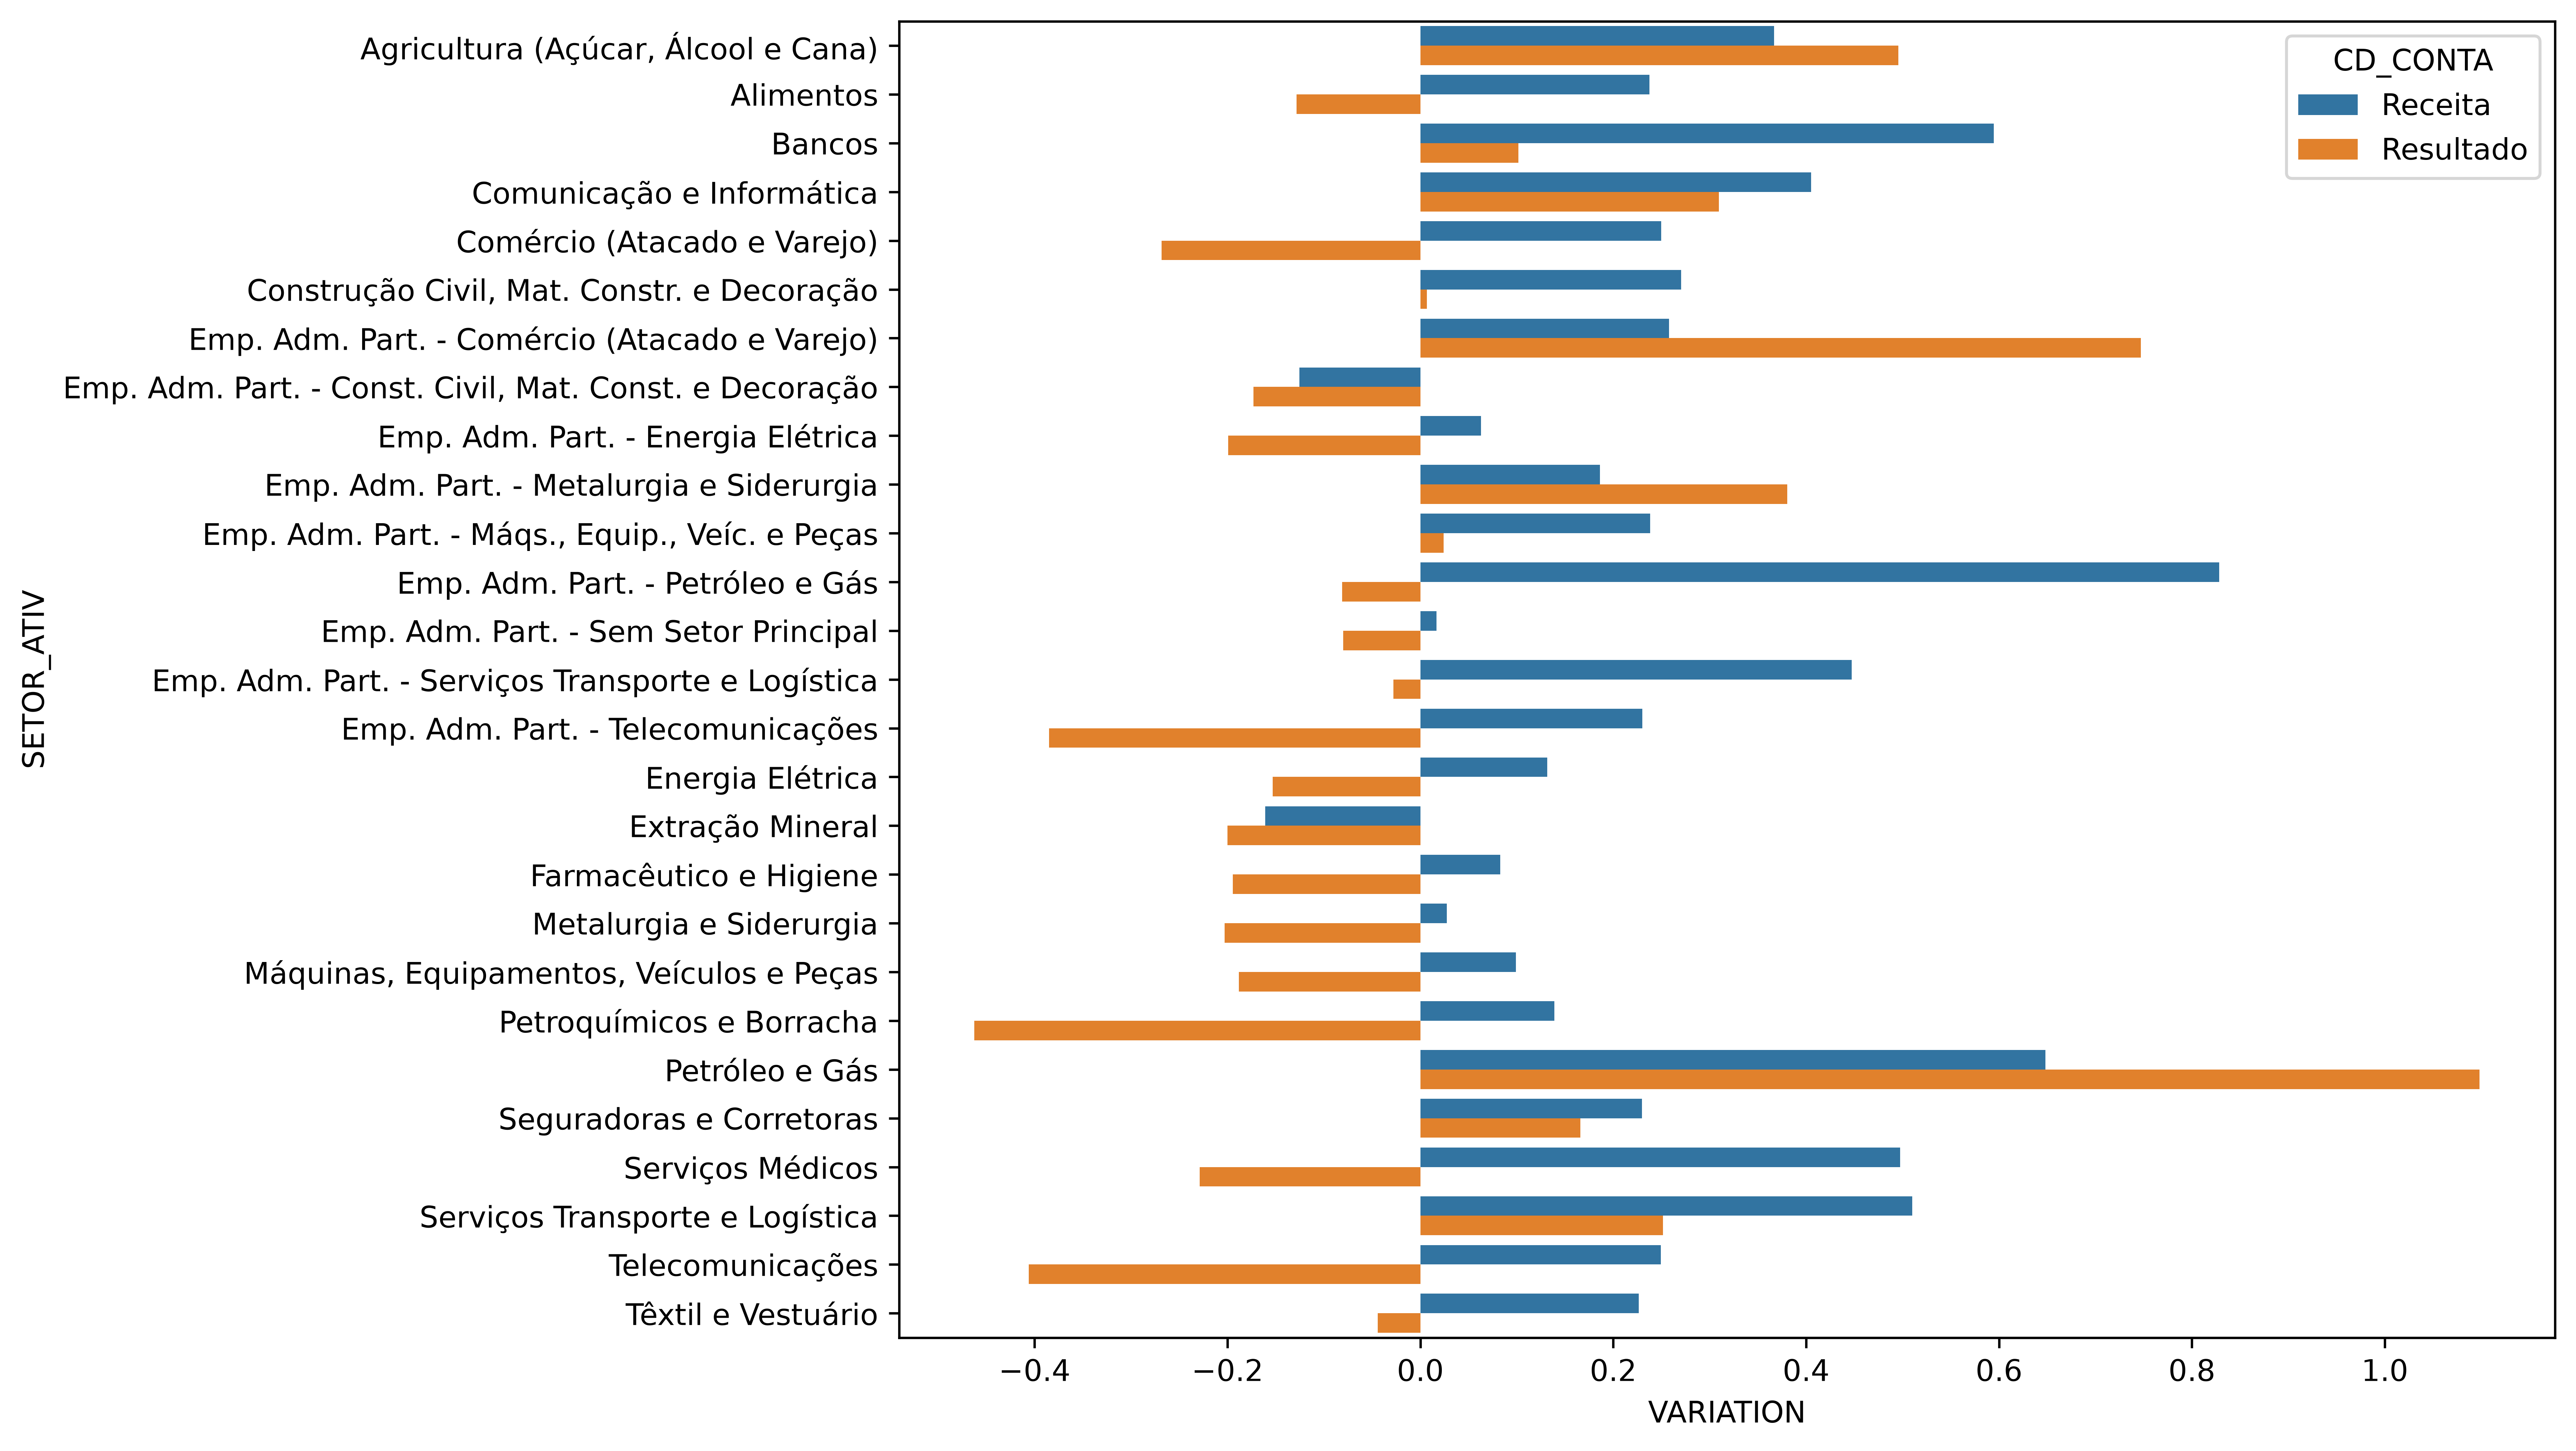

In [35]:
# Graphically
plt.figure(figsize=(10,8), dpi = 600)
sns.barplot(data=per_sector_variation, y='SETOR_ATIV', x='VARIATION', hue='CD_CONTA')
plt.show()

In [36]:
# at the graph above we have our final analysis, taking into consideration the main sectors and the mean variation on
# both their revenue and result accounts